In [ ]:
# Setup - run this cell first. It installs the `jigsaw` package from GitHub and downloads the released weights.
# The rest of the notebook is self-contained (the package mirrors the code in this notebook, see src/jigsaw).
import os, subprocess, sys, urllib.request

GITHUB_USER = "matinmonshizadeh"          # change once: used for the package install and the weights URL
REPO_URL = f"https://github.com/{GITHUB_USER}/jigsaw-puzzle-reconstruction"
WEIGHTS_PATH = "jigsaw.weights.h5"

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", f"git+{REPO_URL}.git"])
if not os.path.exists(WEIGHTS_PATH):
    urllib.request.urlretrieve(f"{REPO_URL}/releases/download/v1.0/jigsaw.weights.h5", WEIGHTS_PATH)
print(f"ready: {WEIGHTS_PATH} ({os.path.getsize(WEIGHTS_PATH) / 1e6:.1f} MB)")


*Course notebook of the Deep Learning exam project (MSc Artificial Intelligence, University of Bologna, 2026).
The cells up to "Additional Constraints" are the instructor's template and are kept verbatim; the solution
starts at "Solution Overview". The same code is packaged in `src/jigsaw` with `train.py` / `evaluate.py`
command-line tools; see the repository README.*


# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [2]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0  # Normalize
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

In [4]:
print(images.shape)

(100000, 96, 96, 3)


In [5]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [6]:
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

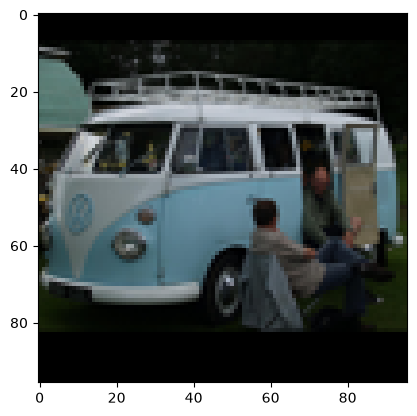

In [7]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [9]:
a,b = test_generator.__getitem__(1)

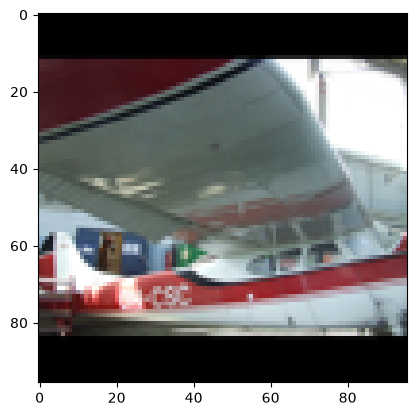

In [10]:
plt.imshow(b[4])

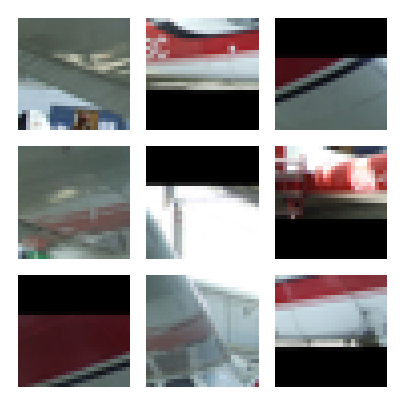

In [11]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [12]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [13]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.1818577, shape=(), dtype=float32)
std: tf.Tensor(0.0020945882, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.


# Solution Overview

## Result
With the published weights, the seeded evaluation on the 10,000 test images gives
**test MAE 0.0428** (mean-patch baseline 0.182), **standard deviation over images 0.0494**,
**78.6%** of patches routed to their exact cell and **45.9%** of puzzles solved completely,
with **3,262,140** trainable parameters. The evaluation section explains each number.

## Approach
The solution is a **pipeline of two neural networks**, trained **end-to-end using only the
inputs `X` and the targets `Y`** (no permutation labels). It works directly with the
provided `PatchGenerator`.

```
X (9 patches)
│
▼
[ OrderNet ]      → predicts a 9×9 soft assignment P (via Sinkhorn)
│
▼
[ Assembly ]      → places the patches on a 96×96 canvas C (+ a known-pixel mask M)
│
▼
[ RefineNet ]     → fills in the missing seams
│
▼
final = M·C + (1−M)·RefineNet(C, M)
```

## Architecture
- **OrderNet** — a small shared CNN encodes each patch, then a few self-attention blocks
  (no positional encoding: the input slot order carries no information) let the patches compare
  with one another, and a final layer outputs a `9×9` score matrix. A **Sinkhorn** normalisation
  turns it into a soft permutation `P` (which patch goes to which cell).
- **Assembly** — `P` places the patches onto a `96×96` canvas. This step is differentiable,
  so the whole pipeline trains together.
- **RefineNet** — a compact U-Net that inpaints the missing seams. The known patch pixels
  are copied straight from the canvas, so the U-Net only has to predict the gaps.

## Key idea: label-free Placement Loss
Each input patch is an exact crop of `Y`, so the correct content for every grid cell is
already inside `Y`. This makes it possible to teach the routing **without any labels**:
the assembled canvas is compared to `Y` on the known pixels only. The error can drop to
zero only when each patch is placed in the correct cell.

**Total loss = placement MAE (known pixels) + reconstruction MAE (full image).**

## Training
- The Sinkhorn temperature is annealed linearly from `1.0` to `0.2` across the 60 scheduled
  epochs, so the assignment sharpens gradually; at evaluation a low temperature (`0.01`) is used.
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping` (restores the best weights) and a
  `ModelCheckpoint`; the best checkpoint is reloaded explicitly after training.
- A `place` metric tracks routing accuracy during training (monitoring only; it is a lower
  bound, see the evaluation section for the exact metrics).

## What the network outputs at test time
Where OrderNet is confident, the Sinkhorn output is a permutation for all practical purposes
(entries above 0.999). Where two patches are equally plausible for the same cell (typically
visually similar or identical patches), Sinkhorn returns a **soft, convex blend** of the
candidates instead of a hard choice, and the reconstructed cell is the corresponding blend.
This is a property of the network's forward pass, not a post-processing step. It is visible
in the qualitative section as ghosted cells, and it is why the reconstruction MAE is better
than the routing accuracy alone would suggest: a blended cell costs less MAE than committing
to the wrong patch.

## Constraints
- **Neural-only pipeline.** OrderNet ends with a Sinkhorn normalisation layer: 20 alternating
  row/column log-softmax normalisations with no trainable parameters, differentiable and trained
  end-to-end with the rest of the network (Mena et al., *Learning latent permutations with
  Gumbel-Sinkhorn networks*, ICLR 2018). It is a normalisation in the same sense as softmax, to
  which it reduces for a single iteration; it is not a discrete solver. No Hungarian matching,
  search or post-processing is applied at any stage: the submitted output is the network's
  forward pass. The patch assembly is a fixed, differentiable tensor operation (like the
  sampling step of a spatial transformer).
- No pretrained models.
- Trainable parameters below 6,000,000: **3,262,140** (printed and asserted by the build cell;
  BatchNorm moving statistics are non-trainable and excluded).
- Implemented in Keras; the trained weights are published as a GitHub release and downloaded by the first cell.

## How to run
- `TRAIN = False` (default, set in the configuration cell): evaluates the released weights (about
  13 MB, fetched by the first cell). "Run all" takes a few minutes on a Colab GPU, dominated by
  the STL-10 download.
- `TRAIN = True`: retrains from scratch (about 2 h on a Colab T4) and evaluates the new weights.


In [ ]:
# ---------------- Configuration ----------------
TRAIN = False   # True : retrain from scratch (~2 h on a Colab T4), then evaluate the new weights.
                # False: evaluate the released weights downloaded by the first cell (WEIGHTS_PATH).
SEED = 0
keras.utils.set_random_seed(SEED)   # seeds python, numpy and tf (weight init, training data order / permutations)


In [15]:
import numpy as np

# ---------- OrderNet: 9 patches -> (9 slots x 9 positions) logits ----------
def build_patch_encoder():
    """Shared CNN that embeds one 28x28x3 patch into a 128-d vector."""
    inp = layers.Input((28, 28, 3))
    x = layers.Conv2D(32, 3, padding="same")(inp); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)   # 14
    x = layers.Conv2D(64, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)   # 7
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)  # 4
    x = layers.GlobalAveragePooling2D()(x)                                                                            # 128
    return keras.Model(inp, x, name="patch_encoder")

def build_ordernet():
    inp = layers.Input((9, 28, 28, 3))
    tokens = layers.TimeDistributed(build_patch_encoder())(inp)          # (9, 128) ; permutation-equivariant set
    x = tokens
    for _ in range(3):                                                   # self-attention lets patches compare to each other
        a = layers.LayerNormalization()(x)
        a = layers.MultiHeadAttention(num_heads=4, key_dim=32)(a, a)
        x = layers.Add()([x, a])
        f = layers.LayerNormalization()(x)
        f = layers.Dense(256, activation="relu")(f)
        f = layers.Dense(128)(f)
        x = layers.Add()([x, f])
    logits = layers.Dense(9)(x)                                          # (9 slots, 9 positions)
    return keras.Model(inp, logits, name="ordernet")

# ---------- RefineNet: assembled canvas (+known mask) -> full 96x96 ----------
def build_refinenet(base=48):
    def cbr(x, f):
        x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        return x
    inp = layers.Input((96, 96, 4))                                      # 3 rgb + 1 known-pixel mask
    c1 = cbr(cbr(inp, base), base);            p1 = layers.MaxPool2D()(c1)        # 96 -> 48
    c2 = cbr(cbr(p1, base*2), base*2);         p2 = layers.MaxPool2D()(c2)        # 48 -> 24
    c3 = cbr(cbr(p2, base*4), base*4);         p3 = layers.MaxPool2D()(c3)        # 24 -> 12
    b  = cbr(cbr(p3, base*4), base*4)                                            # 12
    u3 = layers.UpSampling2D()(b);  u3 = layers.Concatenate()([u3, c3]); u3 = cbr(cbr(u3, base*4), base*4)
    u2 = layers.UpSampling2D()(u3); u2 = layers.Concatenate()([u2, c2]); u2 = cbr(cbr(u2, base*2), base*2)
    u1 = layers.UpSampling2D()(u2); u1 = layers.Concatenate()([u1, c1]); u1 = cbr(cbr(u1, base), base)
    out = layers.Conv2D(3, 1, activation="sigmoid")(u1)
    return keras.Model(inp, out, name="refinenet")

In [16]:
class JigsawTrainer(keras.Model):
    """
    Pipeline trained ONLY on (X, Y):
      OrderNet -> Sinkhorn(P) -> differentiable assemble(canvas C) -> RefineNet -> final.
    Placement Loss  = MAE(C, Y) over known pixels  -> label-free routing supervision.
    Reconstruction  = MAE(final, Y)                -> trains seam inpainting.
    'place' metric   = routing monitor recovered from Y (training-time monitoring only; see routing_accuracy).
    """
    def __init__(self, ordernet, refinenet, w_place=1.0,
                 train_tau=1.0, eval_tau=0.01, n_iters=20, **kw):
        super().__init__(**kw)
        self.ordernet, self.refinenet = ordernet, refinenet
        self.w_place, self.eval_tau, self.n_iters = w_place, eval_tau, n_iters
        # Non-trainable tf.Variable: the annealing callback updates it while train_step runs as a
        # compiled graph. It is not a model weight (not counted in the budget, not saved).
        self.train_tau = tf.Variable(train_tau, trainable=False, dtype=tf.float32, name="train_tau")
        m = np.zeros((96, 96), np.float32)
        for r in range(3):
            for c in range(3):
                m[r*32+2:r*32+30, c*32+2:c*32+30] = 1.0          # exactly the pixels PatchGenerator keeps
        self.mask = tf.constant(m.reshape(1, 96, 96, 1))
        self.loss_t  = keras.metrics.Mean(name="loss")
        self.recon_t = keras.metrics.Mean(name="recon")
        self.pmae_t  = keras.metrics.Mean(name="pmae")
        self.place_t = keras.metrics.Mean(name="place")

    @property
    def metrics(self):
        return [self.loss_t, self.recon_t, self.pmae_t, self.place_t]

    def sinkhorn(self, A, tau):
        """Log-domain Sinkhorn: alternating row / column log-softmax normalisations (no parameters).
        The last step normalises the columns, so every destination cell receives a convex
        combination of the patches."""
        la = A / tau
        for _ in range(self.n_iters):
            la = la - tf.reduce_logsumexp(la, axis=2, keepdims=True)   # rows    (slot i) sum to 1
            la = la - tf.reduce_logsumexp(la, axis=1, keepdims=True)   # columns (cell j) sum to 1
        return tf.exp(la)

    def assemble(self, X, P):
        pos = tf.einsum("bij,bihwc->bjhwc", P, X)                    # cell j <- sum_i P[i,j] * patch i
        pos = tf.pad(pos, [[0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])  # 28x28 patch centred in a 32x32 cell
        pos = tf.reshape(pos, (-1, 3, 3, 32, 32, 3))                 # (B, r, c, h, w, ch)
        pos = tf.transpose(pos, [0, 1, 3, 2, 4, 5])                  # (B, r, h, c, w, ch)
        return tf.reshape(pos, (-1, 96, 96, 3))

    def extract_cells(self, Y):
        y = tf.reshape(Y, (-1, 3, 32, 3, 32, 3))                     # (B, r, h, c, w, ch)
        y = tf.transpose(y, [0, 1, 3, 2, 4, 5])                      # (B, r, c, h, w, ch)
        y = tf.reshape(y, (-1, 9, 32, 32, 3))
        return y[:, :, 2:30, 2:30, :]                                # same centre crop as PatchGenerator

    def forward(self, X, tau, training=False):
        P = self.sinkhorn(self.ordernet(X, training=training), tau)
        C = self.assemble(X, P)
        Mb = tf.broadcast_to(self.mask, (tf.shape(C)[0], 96, 96, 1))
        ref = self.refinenet(tf.concat([C, Mb], axis=-1), training=training)
        final = self.mask * C + (1.0 - self.mask) * ref
        return P, C, final

    def call(self, X, training=False):
        tau = self.train_tau if training else self.eval_tau
        return self.forward(X, tau, training)[2]

    def masked_mae(self, C, Y):
        num = tf.reduce_sum(tf.abs(C - Y) * self.mask)
        den = tf.reduce_sum(self.mask) * tf.cast(tf.shape(C)[0], tf.float32) * 3.0
        return num / den

    def routing_accuracy(self, X, Y, P):
        """Training-time monitor only. The 'true' cell of each patch is recovered from Y by nearest
        content (exact whenever the 9 patches are distinct). Images with pixel-identical patches
        (e.g. black letterbox bars, flat sky) make that label ambiguous, so this monitor is a
        LOWER BOUND on routing accuracy. The evaluation section reports the exact
        (true-permutation) and content-equivalent accuracies instead."""
        cells = self.extract_cells(Y)
        Xf = tf.reshape(X, (tf.shape(X)[0], 9, 1, -1))
        Cf = tf.reshape(cells, (tf.shape(X)[0], 1, 9, -1))
        D = tf.reduce_sum(tf.abs(Xf - Cf), axis=-1)
        true_pos = tf.argmin(D, axis=2, output_type=tf.int32)
        pred_pos = tf.argmax(P, axis=2, output_type=tf.int32)
        return tf.reduce_mean(tf.cast(true_pos == pred_pos, tf.float32))

    def _jigsaw_losses(self, X, Y, tau, training):
        P, C, final = self.forward(X, tau, training)
        pmae = self.masked_mae(C, Y)
        recon = tf.reduce_mean(tf.abs(final - Y))
        return P, pmae, recon, self.w_place * pmae + recon

    def train_step(self, data):
        X, Y = data
        with tf.GradientTape() as tape:
            P, pmae, recon, loss = self._jigsaw_losses(X, Y, self.train_tau, True)
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.trainable_variables),
                                            self.trainable_variables))
        acc = self.routing_accuracy(X, Y, P)
        self.loss_t.update_state(loss); self.recon_t.update_state(recon)
        self.pmae_t.update_state(pmae); self.place_t.update_state(acc)
        logs = {m.name: m.result() for m in self.metrics}
        logs["tau"] = tf.identity(self.train_tau)          # the temperature actually used inside the graph
        return logs

    def test_step(self, data):
        X, Y = data
        P, pmae, recon, loss = self._jigsaw_losses(X, Y, self.eval_tau, False)
        acc = self.routing_accuracy(X, Y, P)
        self.loss_t.update_state(loss); self.recon_t.update_state(recon)
        self.pmae_t.update_state(pmae); self.place_t.update_state(acc)
        return {m.name: m.result() for m in self.metrics}


## Building the model and reporting the parameter count

The two sub-networks are built and wrapped into the end-to-end `JigsawTrainer`, which is
then run once on a dummy batch to instantiate all its variables. Key arguments:
- `w_place` — weight of the placement loss relative to the reconstruction loss.
- `train_tau` / `eval_tau` — Sinkhorn temperatures for training and evaluation. `train_tau` is a
  non-trainable `tf.Variable` created in the constructor, so the annealing callback can update it
  while `train_step` runs as a compiled graph; it is not a model weight and does not count toward
  the parameter budget. `eval_tau = 0.01` sharpens the assignment at test time (see the note on
  soft blends above).
- `n_iters` — number of Sinkhorn normalisation iterations.

The optimizer is attached in the training cell (only needed when `TRAIN = True`). The cell prints the trainable parameters of each sub-network and asserts that the whole pipeline
has exactly their sum (the wrapper adds no weights) and stays below 6,000,000. BatchNorm moving
statistics are non-trainable and excluded, as required.


In [17]:
ordernet, refinenet = build_ordernet(), build_refinenet(base=48)
model = JigsawTrainer(ordernet, refinenet, w_place=1.0, train_tau=1.0, eval_tau=0.01, n_iters=20)
_ = model(tf.zeros((2, 9, 28, 28, 3)))   # build variables

print("="*60, "\nOrderNet\n", "="*60)
ordernet.summary()
print("="*60, "\nRefineNet\n", "="*60)
refinenet.summary()

count = lambda variables: int(np.sum([np.prod(v.shape) for v in variables]))
p_order = count(ordernet.trainable_variables)
p_ref   = count(refinenet.trainable_variables)
p_total = count(model.trainable_variables)          # whole pipeline; BatchNorm moving statistics are non-trainable (excluded)
print(f"\nOrderNet trainable params : {p_order:,}")
print(f"RefineNet trainable params: {p_ref:,}")
print(f"TOTAL trainable params    : {p_total:,}   (limit: 6,000,000)")
assert p_total == p_order + p_ref, "the JigsawTrainer wrapper must not add trainable weights"
assert p_total < 6_000_000


OrderNet


Model: "ordernet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 128)    │    140,704 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 128)    │        256 │ time_distributed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 128)    │          0 │ time_distributed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9, 128)    │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 128)    │          0 │ add[0][0],        │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 128)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9, 128)    │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 128)    │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 539,305 (2.06 MB)

 Trainable params: 538,665 (2.05 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 96, 96,    │      1,776 │ input_layer_2[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 96, 96,    │     20,784 │ re_lu_5[0][0]     │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        192 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ re_lu_6[0][0]     │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 48, 48,    │     41,568 │ max_pooling2d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        384 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 48, 48,    │     83,040 │ re_lu_7[0][0]     │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        384 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ re_lu_8[0][0]     │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 24,    │    166,080 │ max_pooling2d_1[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        768 │ conv2d_9[0][0]  

 Total params: 2,726,931 (10.40 MB)

 Trainable params: 2,723,475 (10.39 MB)

 Non-trainable params: 3,456 (13.50 KB)


OrderNet trainable params : 538,665
RefineNet trainable params: 2,723,475
TOTAL trainable params    : 3,262,140   (limit: 6,000,000)


## Training

The **`TauAnneal`** callback lowers the Sinkhorn temperature linearly from `1.0` to `0.2`
across the 60 scheduled epochs, so the soft assignment starts smooth (stable gradients early)
and gradually sharpens toward a hard permutation. The temperature actually used inside the
compiled training graph is logged as `tau` in every epoch. (If early stopping ended a run before
the last epoch, the final temperature would simply be the value reached at that epoch; in the
archived run early stopping did not trigger.)

Training data is produced by the provided `PatchGenerator` (batch 64). The other callbacks are:
- **`ReduceLROnPlateau`** — halves the learning rate when `val_recon` stops improving.
- **`EarlyStopping`** — stops training once `val_recon` plateaus (patience 8) and restores the
  best weights.
- **`ModelCheckpoint`** — saves the best weights to disk. After training, this best checkpoint is
  reloaded explicitly, so the evaluated weights do not depend on Keras' restore behaviour.

Each epoch logs `loss` (total), `recon` (full-image MAE), `pmae` (placement MAE on known
pixels), `place` (routing monitor) and `tau`, plus the `val_` counterparts. `val_recon` is
computed with the evaluation temperature, so it measures exactly the test-time configuration; it
is the quantity used for the learning-rate schedule, early stopping and model selection.

With `TRAIN = False` (default) this cell skips training and loads the released weights instead.


In [ ]:
class TauAnneal(keras.callbacks.Callback):
    """Linearly anneal train_tau from tau_start to tau_end over `anneal_epochs`, then hold.
    The value actually used inside the training graph is reported as the `tau` log entry."""
    def __init__(self, tau_start=1.0, tau_end=0.2, anneal_epochs=60):
        super().__init__()
        self.tau_start, self.tau_end, self.anneal_epochs = tau_start, tau_end, anneal_epochs
    def on_epoch_begin(self, epoch, logs=None):
        frac = min(1.0, epoch / max(1, self.anneal_epochs - 1))          # 0 -> 1, then held
        self.model.train_tau.assign(self.tau_start + (self.tau_end - self.tau_start) * frac)

EPOCHS = 60

if TRAIN:
    model.compile(optimizer=keras.optimizers.Adam(1e-3))
    train_gen = PatchGenerator(train_images, batch_size=64, shuffle=True)
    val_gen   = PatchGenerator(val_images,   batch_size=64, shuffle=False)

    callbacks = [
        TauAnneal(tau_start=1.0, tau_end=0.2, anneal_epochs=EPOCHS),        # same schedule as the archived run
        keras.callbacks.ReduceLROnPlateau(monitor="val_recon", factor=0.5, patience=3,
                                          mode="min", verbose=1),
        keras.callbacks.EarlyStopping(monitor="val_recon", mode="min", patience=8,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint("jigsaw_best.weights.h5", monitor="val_recon", mode="min",
                                        save_best_only=True, save_weights_only=True, verbose=1),
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)
    model.load_weights("jigsaw_best.weights.h5")     # best epoch by val_recon, independent of Keras' restore logic
    # Logs per epoch: loss, recon (full MAE), pmae (placement MAE), place (routing monitor), tau, plus val_* versions.
else:
    model.load_weights(WEIGHTS_PATH)
    print(f"TRAIN = False: loaded the released weights ({WEIGHTS_PATH}).")


In [19]:
if TRAIN:
    import matplotlib.pyplot as plt

    h = history.history
    ep = range(1, len(h["loss"]) + 1)

    panels = [("recon", "Reconstruction MAE  (lower = better)"),
              ("place", "Routing monitor  (higher = better)"),
              ("pmae",  "Placement MAE  (lower = better)"),
              ("loss",  "Total loss")]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (key, title) in zip(axes.ravel(), panels):
        if key in h:           ax.plot(ep, h[key], marker=".", label="train")
        if "val_"+key in h:    ax.plot(ep, h["val_"+key], marker=".", label="val")
        ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(True, alpha=0.3); ax.legend()

    axes[0, 0].axhline(0.182, ls="--", color="gray")          # baseline on the MAE panel
    axes[0, 0].annotate("baseline 0.182", (1, 0.182), color="gray", va="bottom")
    plt.tight_layout(); plt.show()

    # best-epoch summary (by validation MAE)
    best = int(np.argmin(h["val_recon"]))
    print(f"Best epoch: {best+1}  |  val_recon (MAE) = {h['val_recon'][best]:.4f}  "
          f"|  val_place = {h['val_place'][best]*100:.2f}%  |  tau at best epoch = {h['tau'][best]:.3f}")
else:
    print("TRAIN = False: training was skipped, so there is no new history to plot.\n"
          "The curves of the archived training run (which produced the published weights) are shown in the next text cell.")


TRAIN = False: training was skipped, so there is no new history to plot.
The curves of the archived training run (which produced the published weights) are shown in the next text cell.


## Training curves (archived run)

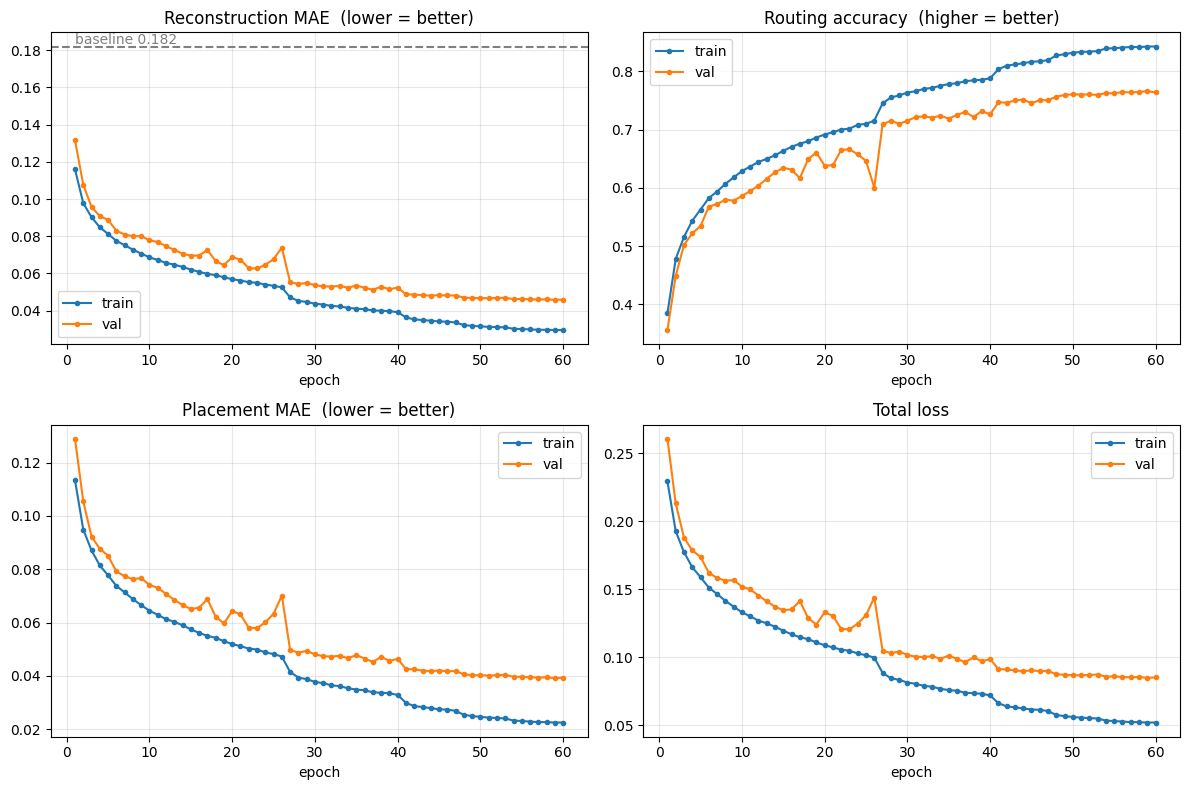

Curves of the training run documented in this notebook (Colab T4, 60 epochs, about 2 minutes per
epoch). Panels: reconstruction MAE, routing monitor, placement MAE and total loss, train vs.
validation; the dashed line marks the `0.182` baseline. Best epoch by `val_recon`: **59**, with
validation MAE **0.0458** (about 4x better than the baseline) and validation routing monitor
76.63%.

**Reading the curves.** All metrics improve smoothly; the two steps near epochs 27 and 41 are
learning-rate halvings. The train/validation gap (MAE 0.030 vs 0.046, routing monitor 0.84 vs
0.77) indicates moderate overfitting, but the validation curve is still flat-to-improving at the
end, which is why the best epoch is the second-to-last one. The routing panel uses the strict
`place` monitor (a patch counts as correct only if it is sent to the cell chosen by
nearest-content matching), which is a lower bound on the content-equivalent accuracy reported in
the evaluation section below.


## Test evaluation

Evaluation uses a seeded, unshuffled copy of the provided generator (`EvalPatchGenerator`: same
patches, same centre crop and same random-permutation logic, but with a fixed per-batch seed and
access to the true permutation), so the numbers below are exactly reproducible.

Reported quantities:
- **Test MAE** — mean absolute error between the reconstruction and the original image, in
  `[0, 1]` units, averaged over all pixels of the 10,000 test images (the required metric).
- **Standard deviation** — computed over the 10,000 per-image MAE values. (The standard deviation
  of batch means is printed only for reference; it is smaller by roughly the square root of the
  batch size and is not a property of single images.)
- **Routing accuracy, exact** — fraction of patches sent to their true cell according to the
  generator's permutation.
- **Routing accuracy, content-equivalent** — fraction of patches sent to a cell whose true content
  is pixel-identical to the patch. It differs from the exact figure only for images containing
  identical patches (e.g. black letterbox bars or flat sky), where any assignment among them is
  equally correct and yields the same image.
- **Puzzles fully solved** — images with all 9 patches exactly in place.

A single forward pass (`model.forward`) returns the assignment `P`, the canvas and the final image.


In [21]:
# ===== Test evaluation: reproducible, per-image statistics, exact & content-equivalent routing =====

class EvalPatchGenerator(PatchGenerator):
    """The provided PatchGenerator with (a) a deterministic per-batch RNG and (b) access to the true
    permutation. __getitem__ returns exactly what PatchGenerator returns; get_batch_with_order also
    returns `order`, where order[slot] is the original grid position (0-8) of the patch in that slot."""
    def __init__(self, images, batch_size=64, seed=0, **kw):
        super().__init__(images, batch_size=batch_size, shuffle=False, **kw)
        self.seed = seed

    def get_batch_with_order(self, idx):
        rng = np.random.RandomState(self.seed * 1_000_003 + idx)
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        n, ps, cs = len(batch_indices), self.patch_size, self.crop_size
        m = (ps - cs) // 2
        X = np.zeros((n, 9, cs, cs, 3), "float32")
        Y = np.zeros((n, 96, 96, 3), "float32")
        order = np.zeros((n, 9), np.int32)
        for i, k in enumerate(batch_indices):
            img = self.images[k].astype("float32") / 255.0
            Y[i] = img
            cells = [img[r*ps + m : r*ps + m + cs, c*ps + m : c*ps + m + cs]
                     for r in range(3) for c in range(3)]
            order[i] = rng.permutation(9)
            for slot, pos in enumerate(order[i]):
                X[i, slot] = cells[pos]
        return X, Y, order

    def __getitem__(self, idx):
        X, Y, _ = self.get_batch_with_order(idx)
        return X, Y


def evaluate(model, images, batch_size=64, seed=SEED):
    """Per-image MAE (mean and std over images) and three routing accuracies."""
    gen = EvalPatchGenerator(images, batch_size=batch_size, seed=seed)
    per_image_mae, exact_ok, content_ok = [], [], []
    for i in range(len(gen)):
        X, Y, order = gen.get_batch_with_order(i)
        P, C, pred = model.forward(X, model.eval_tau, training=False)   # one forward pass
        P, pred = P.numpy(), pred.numpy()
        per_image_mae.append(np.abs(pred - Y).mean(axis=(1, 2, 3)))     # one value per image
        pred_pos = P.argmax(axis=2)                                      # cell chosen for each slot
        exact_ok.append(pred_pos == order)                               # exact permutation
        cells = model.extract_cells(Y).numpy()                           # (n,9,28,28,3), cell order
        placed = np.take_along_axis(cells, pred_pos[:, :, None, None, None], axis=1)
        content_ok.append(np.abs(placed - X).mean(axis=(2, 3, 4)) == 0)  # exact crops -> 0 iff right
    per_image_mae = np.concatenate(per_image_mae)
    exact_ok, content_ok = np.concatenate(exact_ok), np.concatenate(content_ok)
    assert per_image_mae.shape == (len(images),)
    return dict(mae=per_image_mae.mean(), std=per_image_mae.std(),
                exact_routing=exact_ok.mean(), content_routing=content_ok.mean(),
                solved=exact_ok.all(axis=1).mean(), per_image_mae=per_image_mae)


res = evaluate(model, test_images, batch_size=64, seed=SEED)
mae_img = res["per_image_mae"]
batch8_std = mae_img[: len(mae_img) // 8 * 8].reshape(-1, 8).mean(axis=1).std()
print(f"Test MAE (mean over {len(mae_img):,} images)   : {res['mae']:.5f}   (mean-patch baseline: 0.182)")
print(f"Standard deviation of per-image MAE       : {res['std']:.5f}")
print(f"  (std of batch-of-8 means, for reference : {batch8_std:.5f})")
print(f"Routing accuracy, exact permutation       : {res['exact_routing']*100:.2f}%")
print(f"Routing accuracy, content-equivalent      : {res['content_routing']*100:.2f}%")
print(f"Puzzles with all 9 patches exactly placed : {res['solved']*100:.2f}%")


Test MAE (mean over 10,000 images)   : 0.04276   (mean-patch baseline: 0.182)
Standard deviation of per-image MAE       : 0.04937
  (std of batch-of-8 means, for reference : 0.01732)
Routing accuracy, exact permutation       : 78.58%
Routing accuracy, content-equivalent      : 78.59%
Puzzles with all 9 patches exactly placed : 45.91%


**Result (published weights, seeded evaluation, 10,000 test images).** Test MAE **0.0428**
against a mean-patch baseline of `0.182`; standard deviation over images **0.0494** (the
standard deviation of batch-of-8 means, the statistic an earlier version of this notebook
reported, is 0.0173). Routing: **78.6%** of patches are sent to their exact cell and 78.6% to a
content-identical cell (pixel-identical patches are rare in this test set), and **45.9%** of the
puzzles are solved completely. The test MAE is below the best validation MAE of the archived run
(0.0458): validation and test are different image sets, and the published weights file was saved
to Drive after the run shown above.

**Reading the numbers.** The test MAE is about four times lower than the mean-patch baseline
(`0.182`). The per-image standard deviation is large relative to the mean because the error
distribution is skewed: most images are reconstructed almost exactly (error confined to the thin
seams), while a minority of images with misrouted or blended patches have errors several times
the mean. The gap between the two routing accuracies is the share of patches that are
interchangeable with another patch of the same image; most of the remaining routing errors are
blended (hedged) cells, which cost less MAE than a hard wrong placement.


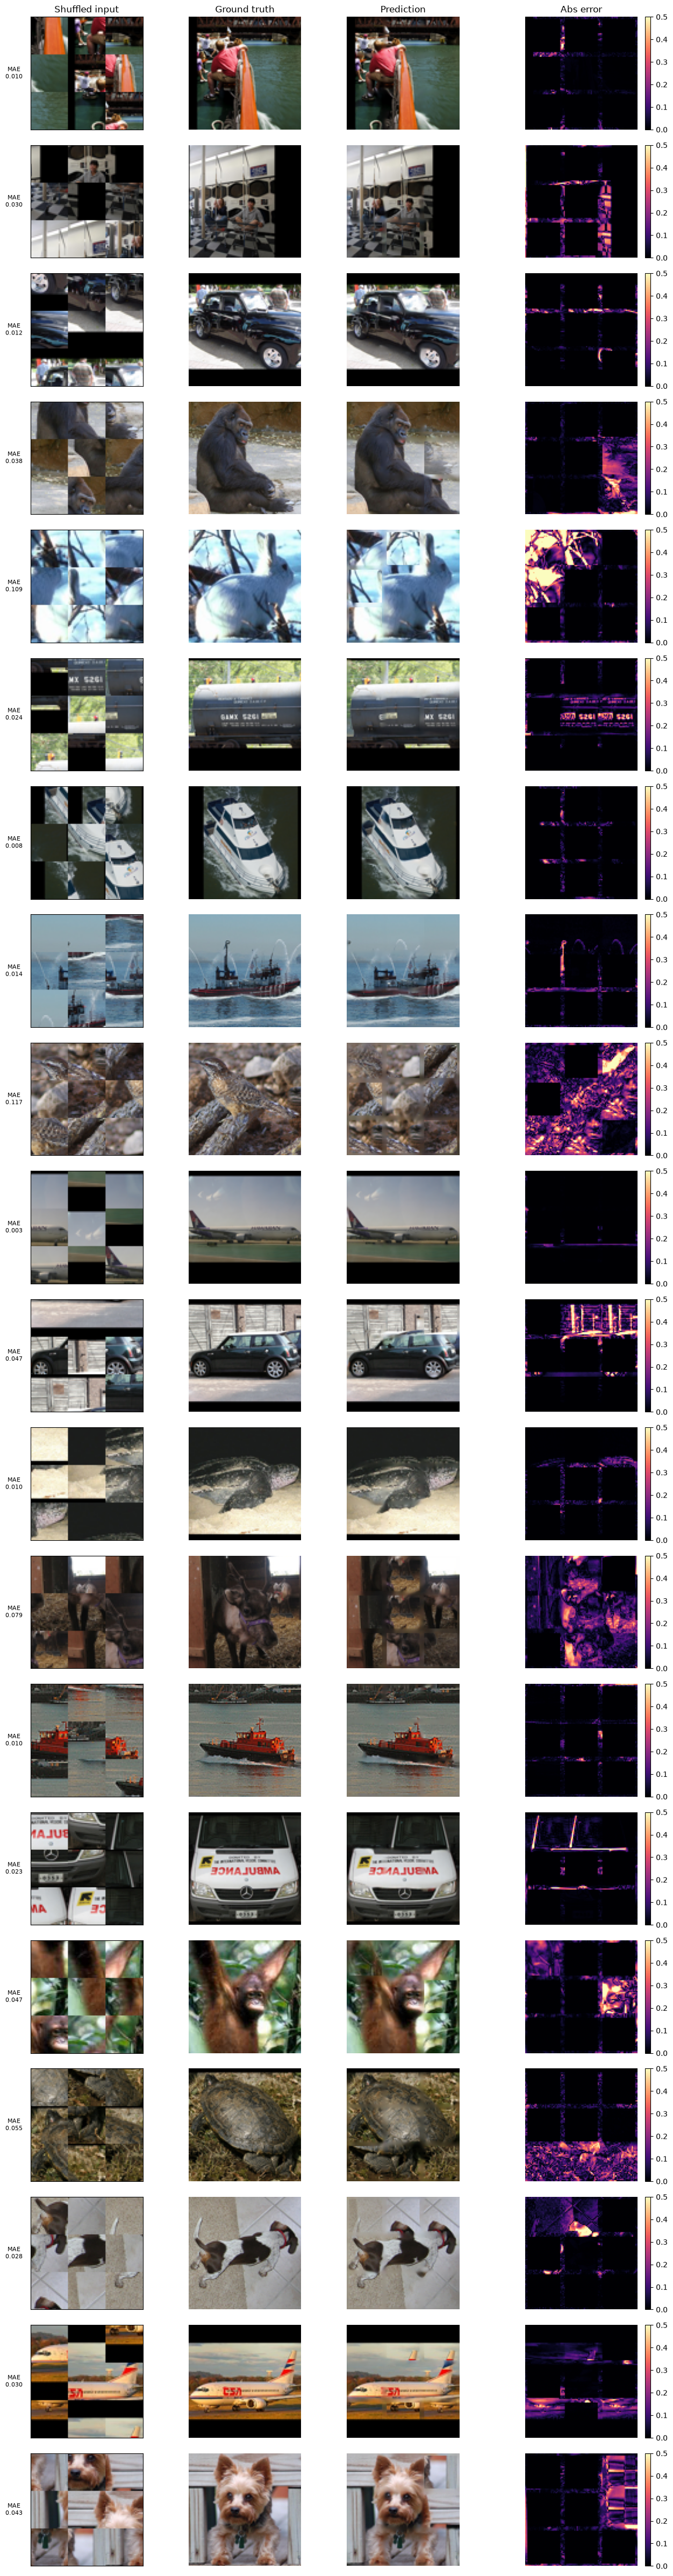

In [22]:
N = 20
VMAX = 0.5   # shared color scale for the abs-error maps (raise/lower to taste)

# N fixed test samples (seeded, so the figure is reproducible)
X, GT, _ = EvalPatchGenerator(test_images, batch_size=N, seed=SEED + 1).get_batch_with_order(0)
PR = np.clip(model(X, training=False).numpy(), 0, 1)

def tile_patches(patches):                       # 9 patches (slot order) -> 84x84 grid
    rows = [np.concatenate([patches[r*3 + c] for c in range(3)], axis=1) for r in range(3)]
    return np.clip(np.concatenate(rows, axis=0), 0, 1)

fig, ax = plt.subplots(N, 4, figsize=(13, 2.4*N))
for k in range(N):
    err = np.mean(np.abs(PR[k] - GT[k]), axis=-1)            # per-pixel abs error
    ax[k,0].imshow(tile_patches(X[k])); ax[k,0].set_xticks([]); ax[k,0].set_yticks([])
    ax[k,0].set_ylabel(f"MAE\n{err.mean():.3f}", fontsize=8, rotation=0, labelpad=22, va="center")
    ax[k,1].imshow(GT[k]); ax[k,1].axis("off")
    ax[k,2].imshow(PR[k]); ax[k,2].axis("off")
    im = ax[k,3].imshow(err, cmap="magma", vmin=0, vmax=VMAX); ax[k,3].axis("off")
    fig.colorbar(im, ax=ax[k,3], fraction=0.046, pad=0.04)

for j, t in enumerate(["Shuffled input", "Ground truth", "Prediction", "Abs error"]):
    ax[0, j].set_title(t, fontsize=12)

plt.tight_layout(); plt.show()


## Qualitative results

For 20 fixed test samples, four columns are shown: the shuffled input patches, the ground-truth
image, the model's reconstruction, and the absolute-error map (mean over RGB, shared color
scale). Each row's MAE is printed on the left.

**Reading the error maps:** a faint grid/cross pattern means the reconstruction is correct
and the only error is along the thin inpainted seams — these are the low-MAE rows. Bright
solid blocks indicate a misrouted patch. A cell that looks semi-transparent or doubled in the
prediction is a *blended* cell: OrderNet hedged between two candidate patches and the Sinkhorn
output placed a convex mix of both (see "What the network outputs at test time" above); such
cells show up as medium-brightness blocks in the error map.

Most samples are reconstructed almost exactly (MAE around 0.01–0.05), with error confined to
the seams. The few high-MAE rows correspond to harder images whose distinct patches were
placed in the wrong cell or blended.


In [ ]:
# Check that the released weights load into a freshly built model and reproduce the evaluated model.
fresh = JigsawTrainer(build_ordernet(), build_refinenet(base=48))
_ = fresh(tf.zeros((2, 9, 28, 28, 3)))
fresh.load_weights(WEIGHTS_PATH)

X, Y = EvalPatchGenerator(test_images, batch_size=64, seed=SEED)[0]
p_fresh = fresh(X, training=False).numpy()
print(f"Reload OK - MAE on one test batch: {np.mean(np.abs(p_fresh - Y)):.4f}")
if not TRAIN:   # the evaluated model was loaded from the same file: the outputs must match
    assert np.allclose(p_fresh, model(X, training=False).numpy(), atol=1e-3), "released weights do not reproduce the evaluated model"
    print("The released weights reproduce the evaluated model.")
